# House Prices

In [20]:
import kagglehub
import os
import pandas as pd 
import seaborn as sns
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt

## Conhecendo o Dataset House Prices

O conjunto de dados House Prices é um conjunto de dados popular usado para tarefas de regressão em aprendizado de máquina. Ele contém informações sobre várias características de casas, como número de quartos, área, localização, entre outras, e o objetivo é prever o preço de venda dessas casas com base nessas características.

## Carregando o Dataset

In [5]:

path = kagglehub.dataset_download("yasserh/housing-prices-dataset")
housing_df = pd.read_csv(os.path.join(path, os.listdir(path)[0]), header=0)
housing_df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
housing_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


## Conhecendo as colunas do Dataset

Temos as seguintes colunas no dataset:

- **price** - Preço de venda da casa.
- **bedrooms** - Número de quartos.
- **bathrooms** - Número de banheiros.
- **stories** - Número de andares.
- **mainroad** - Se a casa está localizada em uma estrada principal (sim/não).
- **guestroom** - Se a casa possui quarto de hóspedes (sim/não).
- **basement** - Se a casa possui porão (sim/não).
- **hotwaterheating** - Se a casa possui aquecimento de água (sim/não).
- **airconditioning** - Se a casa possui ar condicionado (sim/não).
- **parking** - Número de vagas de estacionamento.
- **prefarea** - Se a casa está localizada em uma área preferencial (sim/não).
- **furnishingstatus** - Estado de mobília da casa (mobilada, semi-mobilada, não mobilada).


## Objetivo do estudo

O objetivo deste estudo é analisar o conjunto de dados House Prices e desenvolver um modelo de regressão que possa prever o preço de venda das casas com base em suas características. Isso envolve a exploração dos dados, a seleção de características relevantes, a construção e avaliação do modelo.

## Regressão Linear

A regressão linear é um método estatístico usado para modelar a relação entre uma variável dependente (neste caso, o preço da casa) e uma ou mais variáveis independentes (as características das casas). O modelo de regressão linear tenta encontrar a melhor linha que se ajusta aos dados, minimizando a soma dos quadrados dos resíduos (diferença entre os valores observados e os valores previstos pelo modelo).


$$

Y_{i} = \beta_0 + \beta_1 X_{i1} + \beta_2 X_{i2} + ... + \beta_p X_{ip} + \epsilon_i

$$


$$
\epsilon_i = y_i - \hat{y}_i
$$

$$

Loss = \Sigma_{i=1}^{n} (y_i - \hat{y}_i)^2

$$

# Hands-On

##  Analise Inicial dos Dados

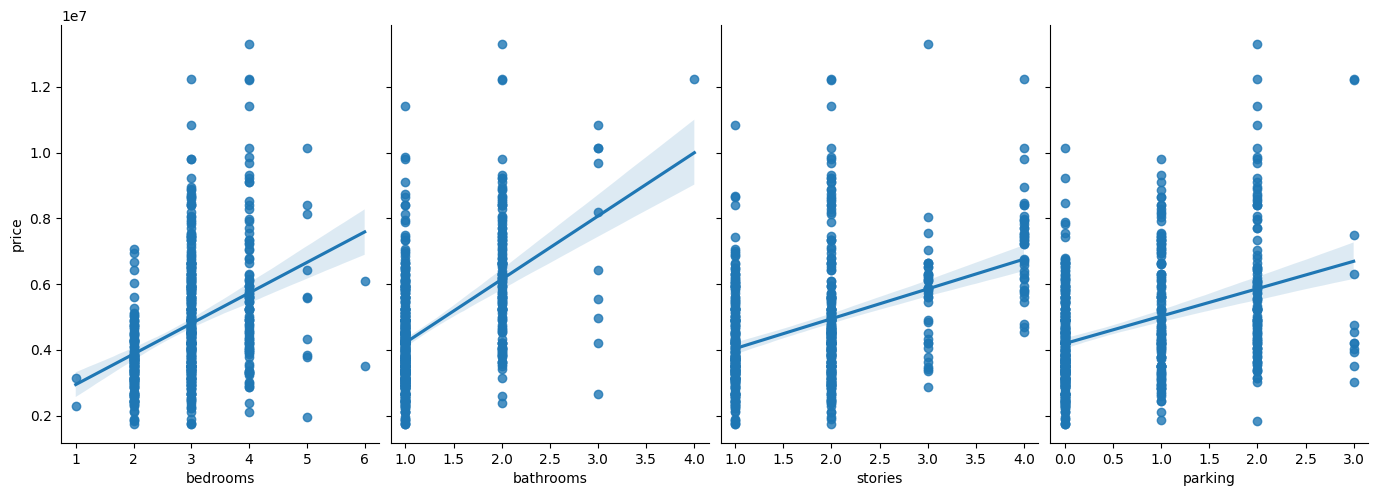

In [7]:
sns.pairplot(housing_df, x_vars=['bedrooms', 'bathrooms', 'stories','parking'], y_vars='price', height=5, aspect=0.7, kind='reg')

## Tranformando Variáveis Categóricas em Numéricas

Para trazer mais informações ao modelo, vamos transformar as variáveis categóricas em numéricas utilizando One-Hot Encoding.

In [13]:
encoding_features = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']
numerical_features = ['bedrooms', 'bathrooms', 'stories', 'parking', 'price']

enc = OneHotEncoder(handle_unknown='ignore', drop='first')
enc.fit(housing_df[encoding_features])
encoded_cols = enc.get_feature_names_out(encoding_features)
encoded_df = pd.DataFrame(enc.transform(housing_df[encoding_features]).toarray(), columns=encoded_cols)
housing_encoded_df = pd.concat([housing_df[numerical_features], encoded_df], axis=1)
housing_encoded_df.head()
X = housing_encoded_df.drop('price', axis=1)
y = housing_encoded_df['price']


## Scikit Learn

In [11]:
lm = LinearRegression()
lm.fit(X, y)
y_pred = lm.predict(X)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R^2 Score: {r2}')

Mean Squared Error: 1971153274402.9375
R^2 Score: 0.43554332400085216


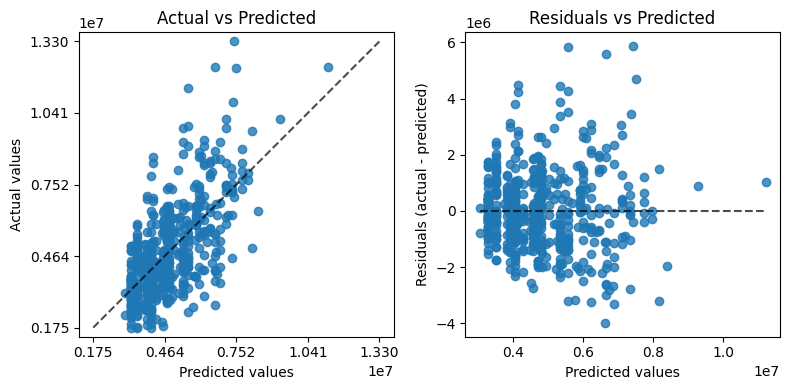

In [ ]:
from sklearn.metrics import PredictionErrorDisplay

fig, axs = plt.subplots(ncols=2, figsize=(8, 4))
PredictionErrorDisplay.from_predictions(y_true=y, y_pred=y_pred, ax=axs[0], kind='actual_vs_predicted')
PredictionErrorDisplay.from_predictions(y_true=y, y_pred=y_pred, ax=axs[1], kind='residual_vs_predicted')
axs[0].set_title("Actual vs Predicted")
axs[1].set_title("Residuals vs Predicted")
plt.tight_layout()
plt.show()

## Statsmodels 

In [26]:
from statsmodels.stats.outliers_influence import OLSInfluence


In [31]:
lm_sm = sm.OLS(y, sm.add_constant(X)).fit()
print(lm_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.436
Model:                            OLS   Adj. R-squared:                  0.431
Method:                 Least Squares   F-statistic:                     104.2
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           1.03e-65
Time:                        19:43:34   Log-Likelihood:                -8487.7
No. Observations:                 545   AIC:                         1.699e+04
Df Residuals:                     540   BIC:                         1.701e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       9.777e+05    2.6e+05      3.757      0.0

In [27]:
influence = OLSInfluence(lm_sm)

In [30]:
influence.summary_table()

obs,endog,fitted,Cook's,student.,hat diag,dffits,ext.stud.,dffits
,,value,d,residual,,internal,residual,
0.0,13300000.0,7433942.366042465,0.03855659125780549,4.181821399673793,0.010903758547960933,0.43907055957901286,4.247286675423974,0.44594408967737353
1.0,12250000.0,11219820.340321152,0.007899342693710062,0.7552483546794471,0.06475966765176039,0.19873780080435202,0.7549475561514667,0.19865864798320965
2.0,12250000.0,6651183.625762336,0.029862125587145363,3.9880783183228345,0.009300479033158312,0.38640733421575585,4.04438933950688,0.3918633433123487
3.0,12215000.0,7527668.547163996,0.04163257175236601,3.3538673495781337,0.018169706334075143,0.45624868083297515,3.386214208653664,0.4606490372704941
4.0,11410000.0,5587866.469463889,0.04262724938188349,4.153242152701667,0.012205328891730163,0.4616668137406212,4.217298818718286,0.46878723576549697
5.0,10850000.0,7388485.594304055,0.04425725410121872,2.4973290146708607,0.03426577556586389,0.4704107465886527,2.50954952808703,0.4727126702863415
6.0,10150000.0,9280018.262621041,0.002373171778814293,0.6260725236037961,0.02938310830329216,0.10893052324335666,0.6257196932621072,0.1088691341992966
7.0,10150000.0,7103389.820565963,0.03745024131217054,2.2013447072939227,0.03720343575150757,0.4327253246123373,2.2092405978212906,0.43427744490510095
8.0,9870000.0,5587866.469463889,0.02305915549642619,3.054677016465155,0.01220532889173016,0.3395523192118277,3.078561556848179,0.34220728110686605
